# Lab1 - PCA


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA

## New York Times data analysis


In [2]:
articles_df = pd.read_csv("data/nyt-frame.csv", header=0)
header = list(articles_df.columns[9:])
data = articles_df.iloc[:, 9:].values

In [3]:
sample_words = np.random.choice(header, 20, replace=False)
print("Sample dictionary words:", sample_words)

Sample dictionary words: ['capture' 'shoulders' 'weight' 'does' 'u' 'heroes' 'effects' 'catalogue'
 'stare' 'share' 'struggle' 'coupled' 'museum' 'absorbing' 'scholar' 'et'
 'brings' 'mens' 'horse' 'verses']


In [4]:
pca = PCA()
x_pca = pca.fit_transform(data)

In [5]:
pc1 = pca.components_[0]
idx_max = np.argsort(pc1)[-15:]
idx_min = np.argsort(pc1)[:15]

print(
    "Top 15 +PC1 words",
    [header[i] for i in idx_max],
)
print(
    "Top 15 -PC1 words",
    [header[i] for i in idx_min],
)

Top 15 +PC1 words ['me', 'he', 'mrs', 'im', 'paintings', 'process', 'painting', 'my', 'cooper', 'mother', 'said', 'i', 'ms', 'her', 'she']
Top 15 -PC1 words ['music', 'trio', 'theater', 'orchestra', 'composers', 'opera', 'theaters', 'm', 'program', 'players', 'festival', 'east', 'y', 'jersey', 'symphony']


> Biggest +PC1 loadings correspond to pronouns, titles and visual art
>
> Smallest -PC1 loadings correspond to music vocabulary
>
> PC1 seems to be arts vs music axis. High PC1 -> more arts, low PC1 -> more music.


In [6]:
pc2 = pca.components_[1]
idx_max = np.argsort(pc2)[-15:]
idx_min = np.argsort(pc2)[:15]

print(
    "Top 15 +PC2 words:",
    [header[i] for i in idx_max],
)
print(
    "Top 15 -PC2 words:",
    [header[i] for i in idx_min],
)

Top 15 +PC2 words: ['vocal', 'orchestra', 'songs', 'musical', 'music', 'festival', 'production', 'sang', 'hour', 'i', 'ms', 'opera', 'theater', 'she', 'her']
Top 15 -PC2 words: ['art', 'museum', 'images', 'artists', 'donations', 'museums', 'painting', 'tax', 'paintings', 'sculpture', 'gallery', 'sculptures', 'painted', 'white', 'service']


> Biggest +PC2 loadings correspond to music vocabulary (performance)
>
> Smallest -PC2 loadings correspond to visual arts & institutions
>
> PC2 seems to be music (+performance) vs visual arts (+collections & institutions) axis. High PC2 -> more music, low PC2 -> more visual arts.


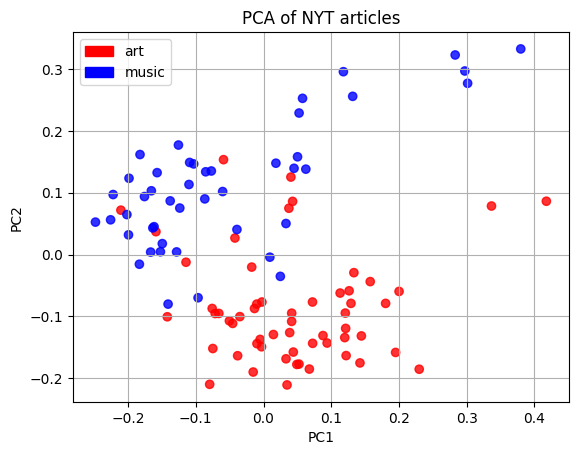

In [7]:
import matplotlib.patches as mpatches

labels = articles_df["class.labels"].values
colors = ["red" if label == "art" else "blue" for label in labels]

plt.figure()
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=colors, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NYT articles")
art_patch = mpatches.Patch(color="red", label="art")
music_patch = mpatches.Patch(color="blue", label="music")
plt.legend(handles=[art_patch, music_patch])
plt.grid()
plt.show()

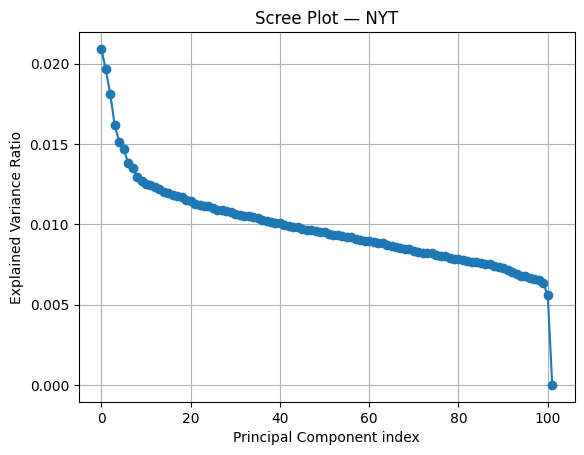

Variance preserved by first 10 PCs: 0.1577 (15.77%)


In [8]:
variance_ratio = pca.explained_variance_ratio_

plt.figure()
plt.plot(variance_ratio, marker="o")
plt.xlabel("Principal Component index")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot — NYT")
plt.grid()
plt.show()

top10_variance = sum(variance_ratio[:10])
print(
    f"Variance preserved by first 10 PCs: {top10_variance:.4f} ({top10_variance * 100:.2f}%)"
)

### `sklearn.decomposition.PCA` arguments

| Argument       | Value               | Comment                                                                                           |
| -------------- | ------------------- | ------------------------------------------------------------------------------------------------- |
| `n_components` | `None` (default)    | Keeps all (4433) components.                                                                      |
|                | `int` e.g. `50`     | Retain exactly _k_ components — explicit budget.                                                  |
|                | `float` e.g. `0.95` | Retain enough PCs to explain ≥ 95% of variance.                                                   |
|                | `'mle'`             | Minka's MLE to estimate intrinsic dimensionality automatically. Useful when true rank is unknown. |
| `copy`         | `False`             | Overwrites input matrix in-place — saves RAM for large datasets, but destroys original data.      |
| `whiten`       | `True`              | Divides each PC score by its standard deviation → unit-variance components.                       |
| `svd_solver`   | `'full'`            | Exact LAPACK SVD — default for small matrices.                                                    |
|                | `'arpack'`          | Partial eigensolver via ARPACK — memory-efficient for large _sparse_ matrices with small _k_.     |
|                | `'randomized'`      | Randomised SVD (Halko et al.).                                                                    |
|                | `'auto'`            | sklearn picks automatically based on data shape and `n_components`.                               |


## 04Cars data analysis


In [9]:
cars_df = pd.read_csv("data/04cars-data.csv", header=0)

In [10]:
data = cars_df.iloc[:, 9:]
data.shape

(387, 11)

In [11]:
from sklearn import preprocessing

scaled_data = preprocessing.scale(data)

In [12]:
scaled_data.mean(axis=0)

array([-4.13106242e-17,  4.13106242e-17, -6.05889155e-16, -1.00981526e-16,
       -1.79012705e-16, -4.59006935e-18, -7.57361443e-17, -2.06553121e-16,
        7.89491929e-16, -6.70150125e-16,  1.78094691e-15])

In [13]:
scaled_data.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [14]:
pca = PCA()
X_pca = pca.fit_transform(scaled_data)
print(pca.explained_variance_ratio_)

[6.45876221e-01 1.71265888e-01 7.72480259e-02 3.24559536e-02
 2.50395994e-02 1.79948832e-02 1.27744735e-02 7.87625563e-03
 6.03527097e-03 3.36157838e-03 7.18504308e-05]


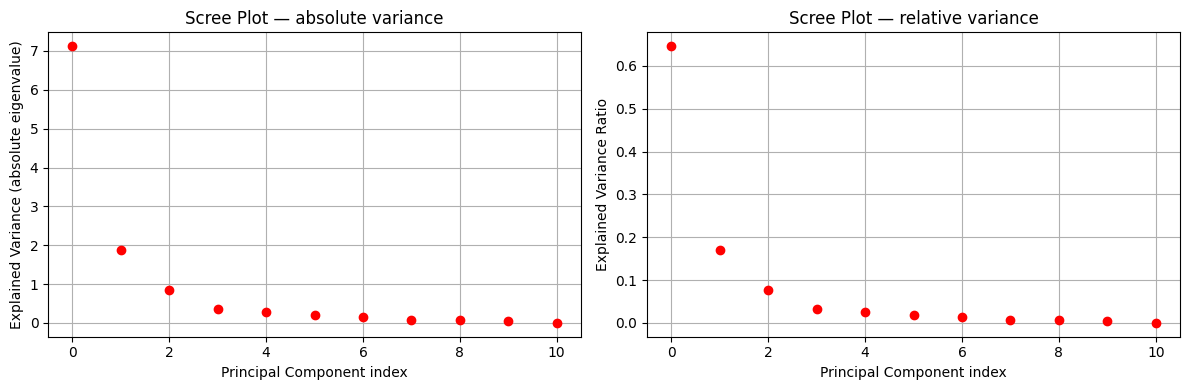

Variance preserved by first 2 PCs: 0.8171 (81.71%)
Variance preserved by first 3 PCs: 0.8944 (89.44%)


In [15]:
variance = pca.explained_variance_ratio_
abs_variance = pca.explained_variance_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(abs_variance, "ro", markersize=6)
axes[0].set_xlabel("Principal Component index")
axes[0].set_ylabel("Explained Variance (absolute eigenvalue)")
axes[0].set_title("Scree Plot — absolute variance")
axes[0].grid()

axes[1].plot(variance, "ro", markersize=6)
axes[1].set_xlabel("Principal Component index")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title("Scree Plot — relative variance")
axes[1].grid()

plt.tight_layout()
plt.show()

cumulative = np.cumsum(variance)
for k in [2, 3]:
    print(
        f"Variance preserved by first {k} PCs: {cumulative[k - 1]:.4f} ({cumulative[k - 1] * 100:.2f}%)"
    )

In [16]:
attributes = cars_df.columns[9:]
attributes

Index(['Retail Price', 'Dealer Cost', 'Engine Size (l)', 'Cyl', 'HP',
       'City MPG', 'Hwy MPG', 'Weight', 'Wheel Base', 'Len', 'Width'],
      dtype='str')

In [ ]:
pc1, pc2 = pca.components_[:2]
loadings_df = pd.DataFrame(
    {
        "Attribute": attributes,
        "PC1": pc1,
        "PC2": pc2,
    }
)
display(loadings_df)

,Attribute,PC1,PC2
0,Retail Price,0.263750,0.468509
1,Dealer Cost,0.262319,0.470147
2,Engine Size (l),0.347080,-0.015347
3,Cyl,0.334189,0.078032
4,HP,0.318602,0.292213
5,City MPG,-0.310482,-0.003366
6,Hwy MPG,-0.306589,-0.010964
7,Weight,0.336329,-0.167464
8,Wheel Base,0.266210,-0.418177
9,Len,0.256790,-0.408411


> Biggest +PC1 loadings correspond to physical bulk and raw power (engine size, cylinders, weight, HP, width).
>
> Smallest -PC1 loadings correspond to fuel efficiency (city and highway MPG).
>
> PC1 seems to be size/power vs fuel-efficiency axis. High PC1 -> large, powerful, thirsty car; low PC1 -> small, efficient car.
>
> Biggest +PC2 loadings correspond to price and performance (retail price, dealer cost, HP).
>
> Smallest -PC2 loadings correspond to physical footprint (wheel base, length, width).
>
> PC2 seems to be price-per-size / luxury axis. High PC2 -> expensive/sporty but compact (sports cars); low PC2 -> spacious but price-competitive (SUVs, trucks).


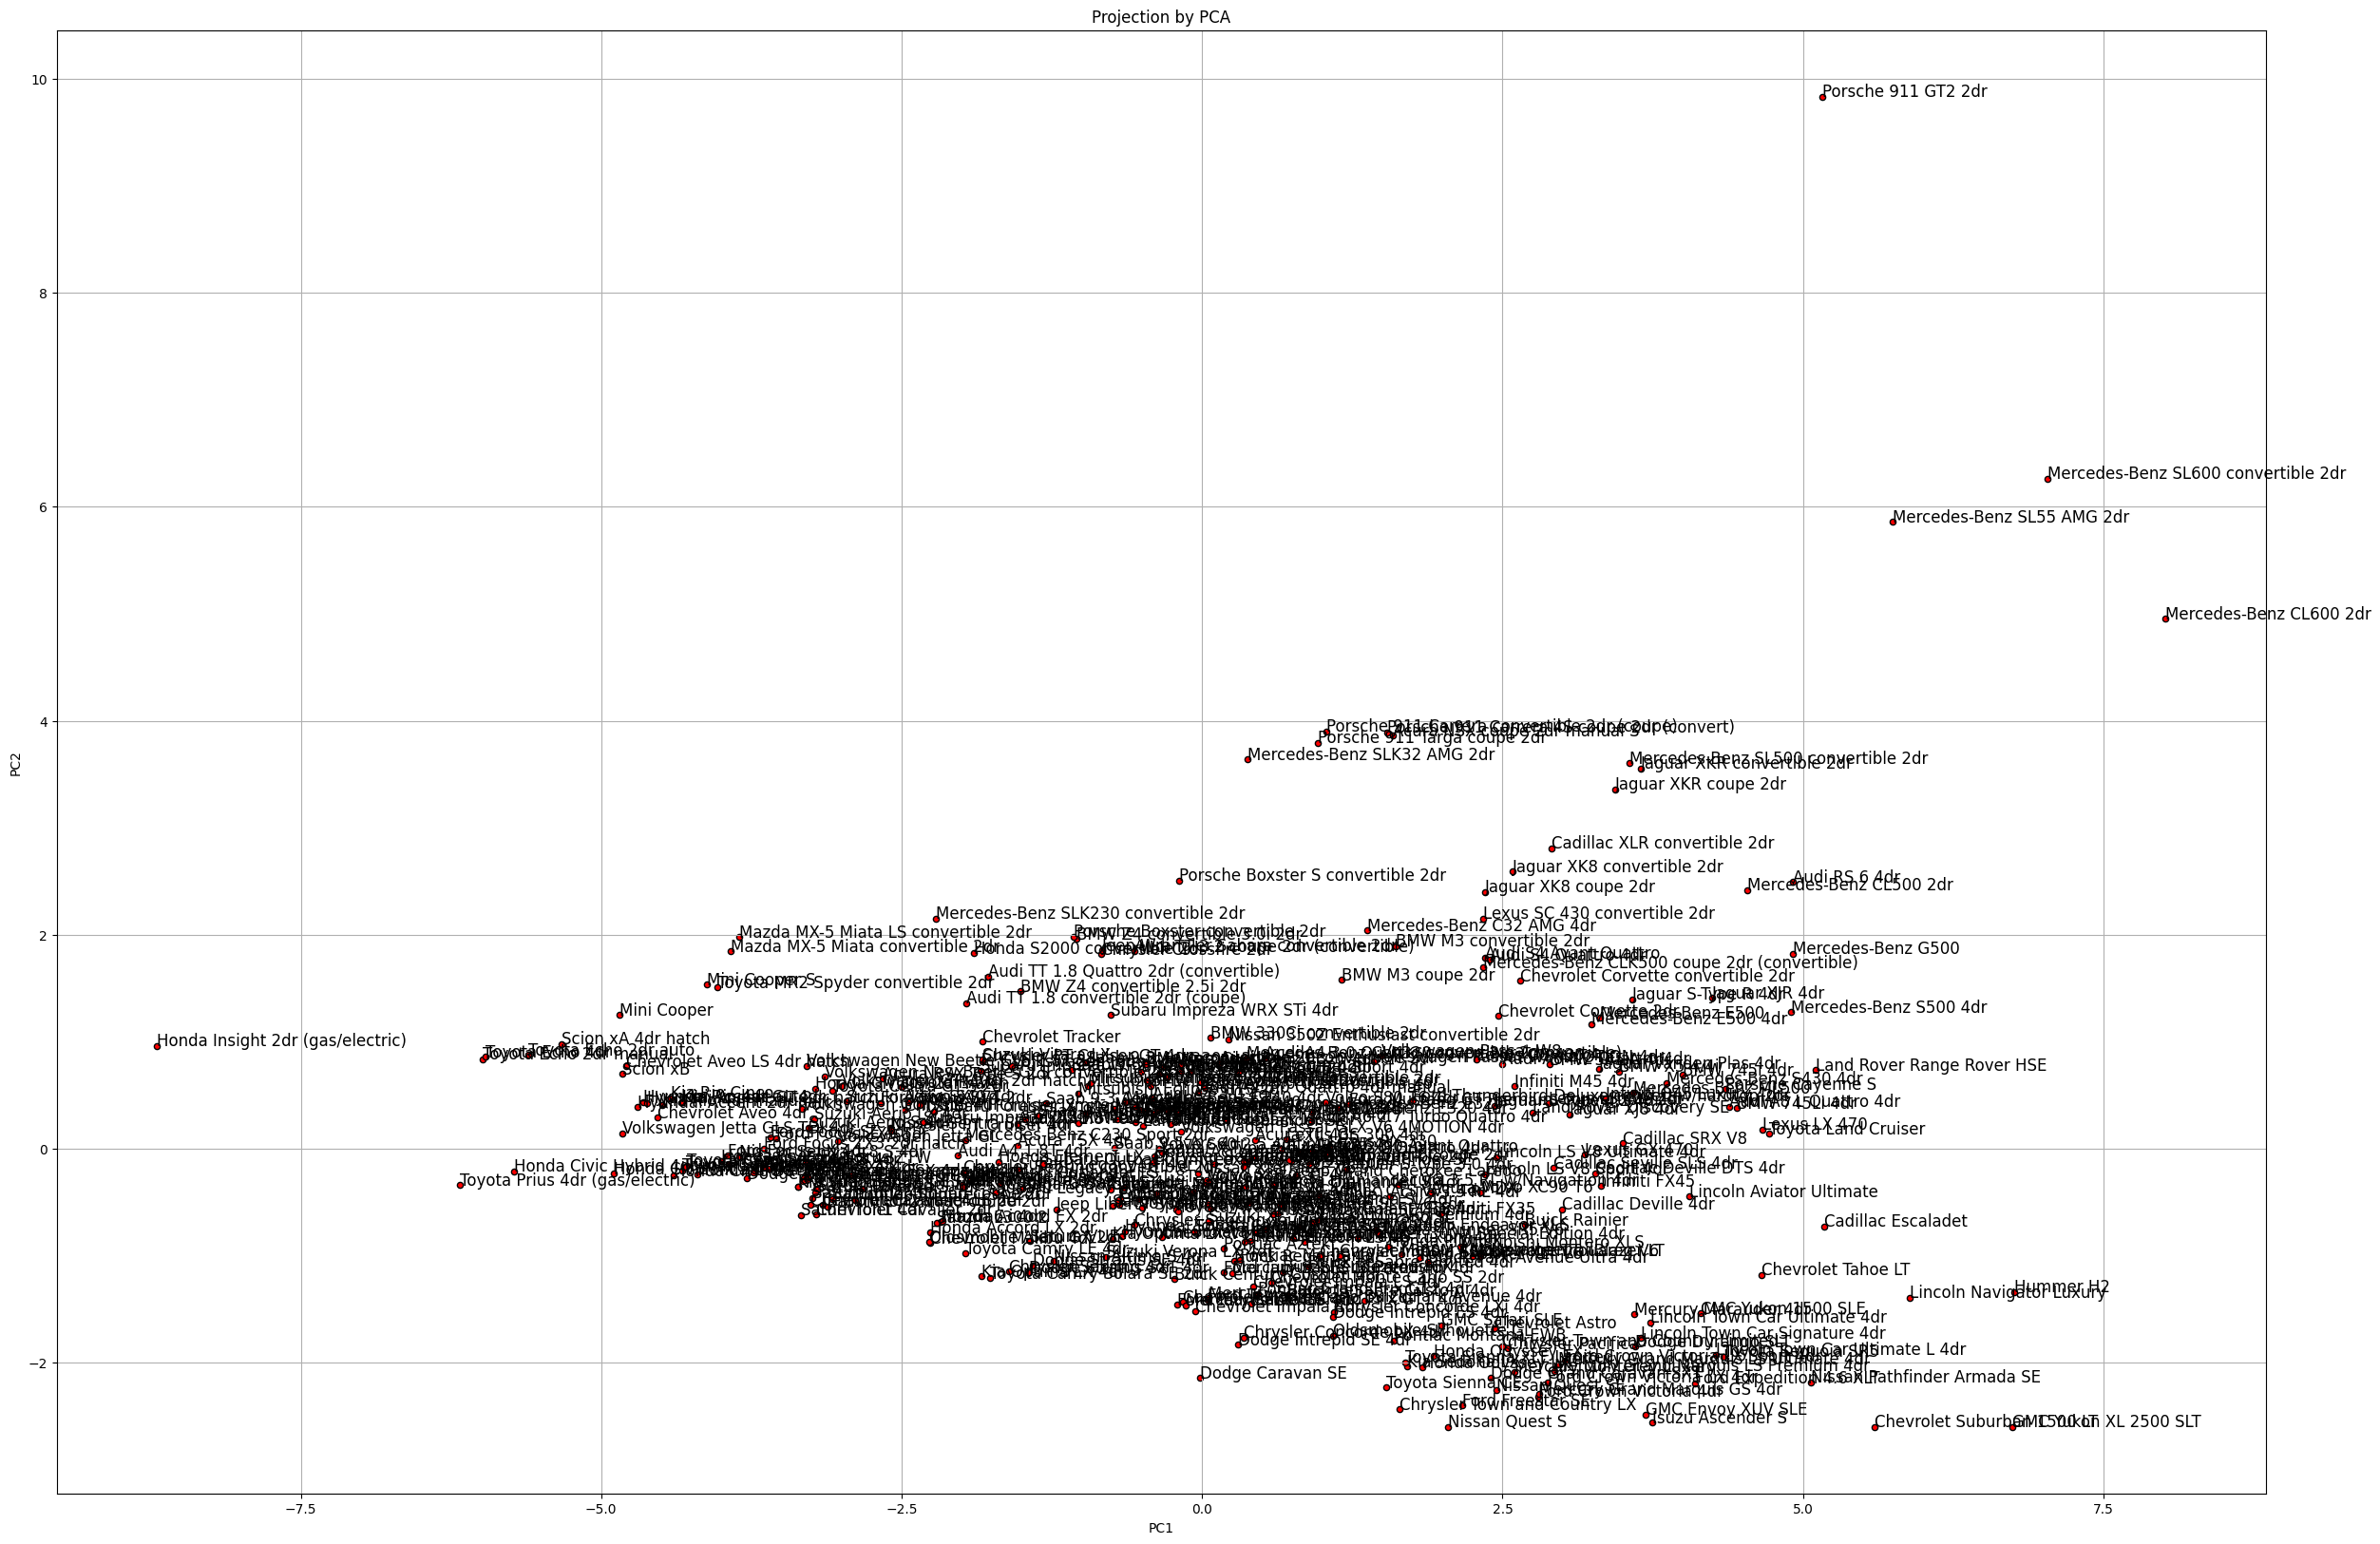

In [18]:
plt.figure(figsize=(30, 20))
x = X_pca[:, 0]
y = X_pca[:, 1]
plt.scatter(x, y, c="red", s=20, edgecolors="k")
plt.title("Projection by PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
labels = list(cars_df.iloc[:, 0])
for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), fontsize=12)
plt.grid()
plt.show()

- **Far right (+PC1):** Large, powerful, fuel-hungry vehicles — full-size trucks, SUVs, muscle cars (e.g. Land Rover, Mercedes Benz G500)
- **Far left (-PC1):** Small, efficient cars — compacts, economy models (e.g. Honda Insight).
- **Top (+PC2):** Expensive, relatively compact, high-HP cars — sports cars and luxury coupes (e.g. Ferrari, Porsche, Maserati). Price and performance are high relative to physical footprint.
- **Bottom (-PC2):** Large-body vehicles that are spacious but price-competitive — minivans, full-size SUVs (e.g. Chevrolet Suburban). Physical dimensions are high relative to price.
- **Centre:** "Average" cars on all attributes.


In [ ]:
def biplot(score, coeff, labels=None):
    plt.figure(figsize=(25, 18))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    plt.scatter(xs * scalex, ys * scaley, c="red", s=20, edgecolors="k")
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color="blue", alpha=0.5)
        if labels is None:
            plt.text(
                coeff[i, 0] * 1.15,
                coeff[i, 1] * 1.15,
                "Var" + str(i + 1),
                color="green",
                ha="center",
                va="center",
            )
        else:
            plt.text(
                coeff[i, 0] * 1.15,
                coeff[i, 1] * 1.15,
                labels[i],
                color="green",
                ha="center",
                va="center",
            )
    axes = plt.gca()
    axes.set_xlim((-1, 1))
    axes.set_ylim((-1, 1))

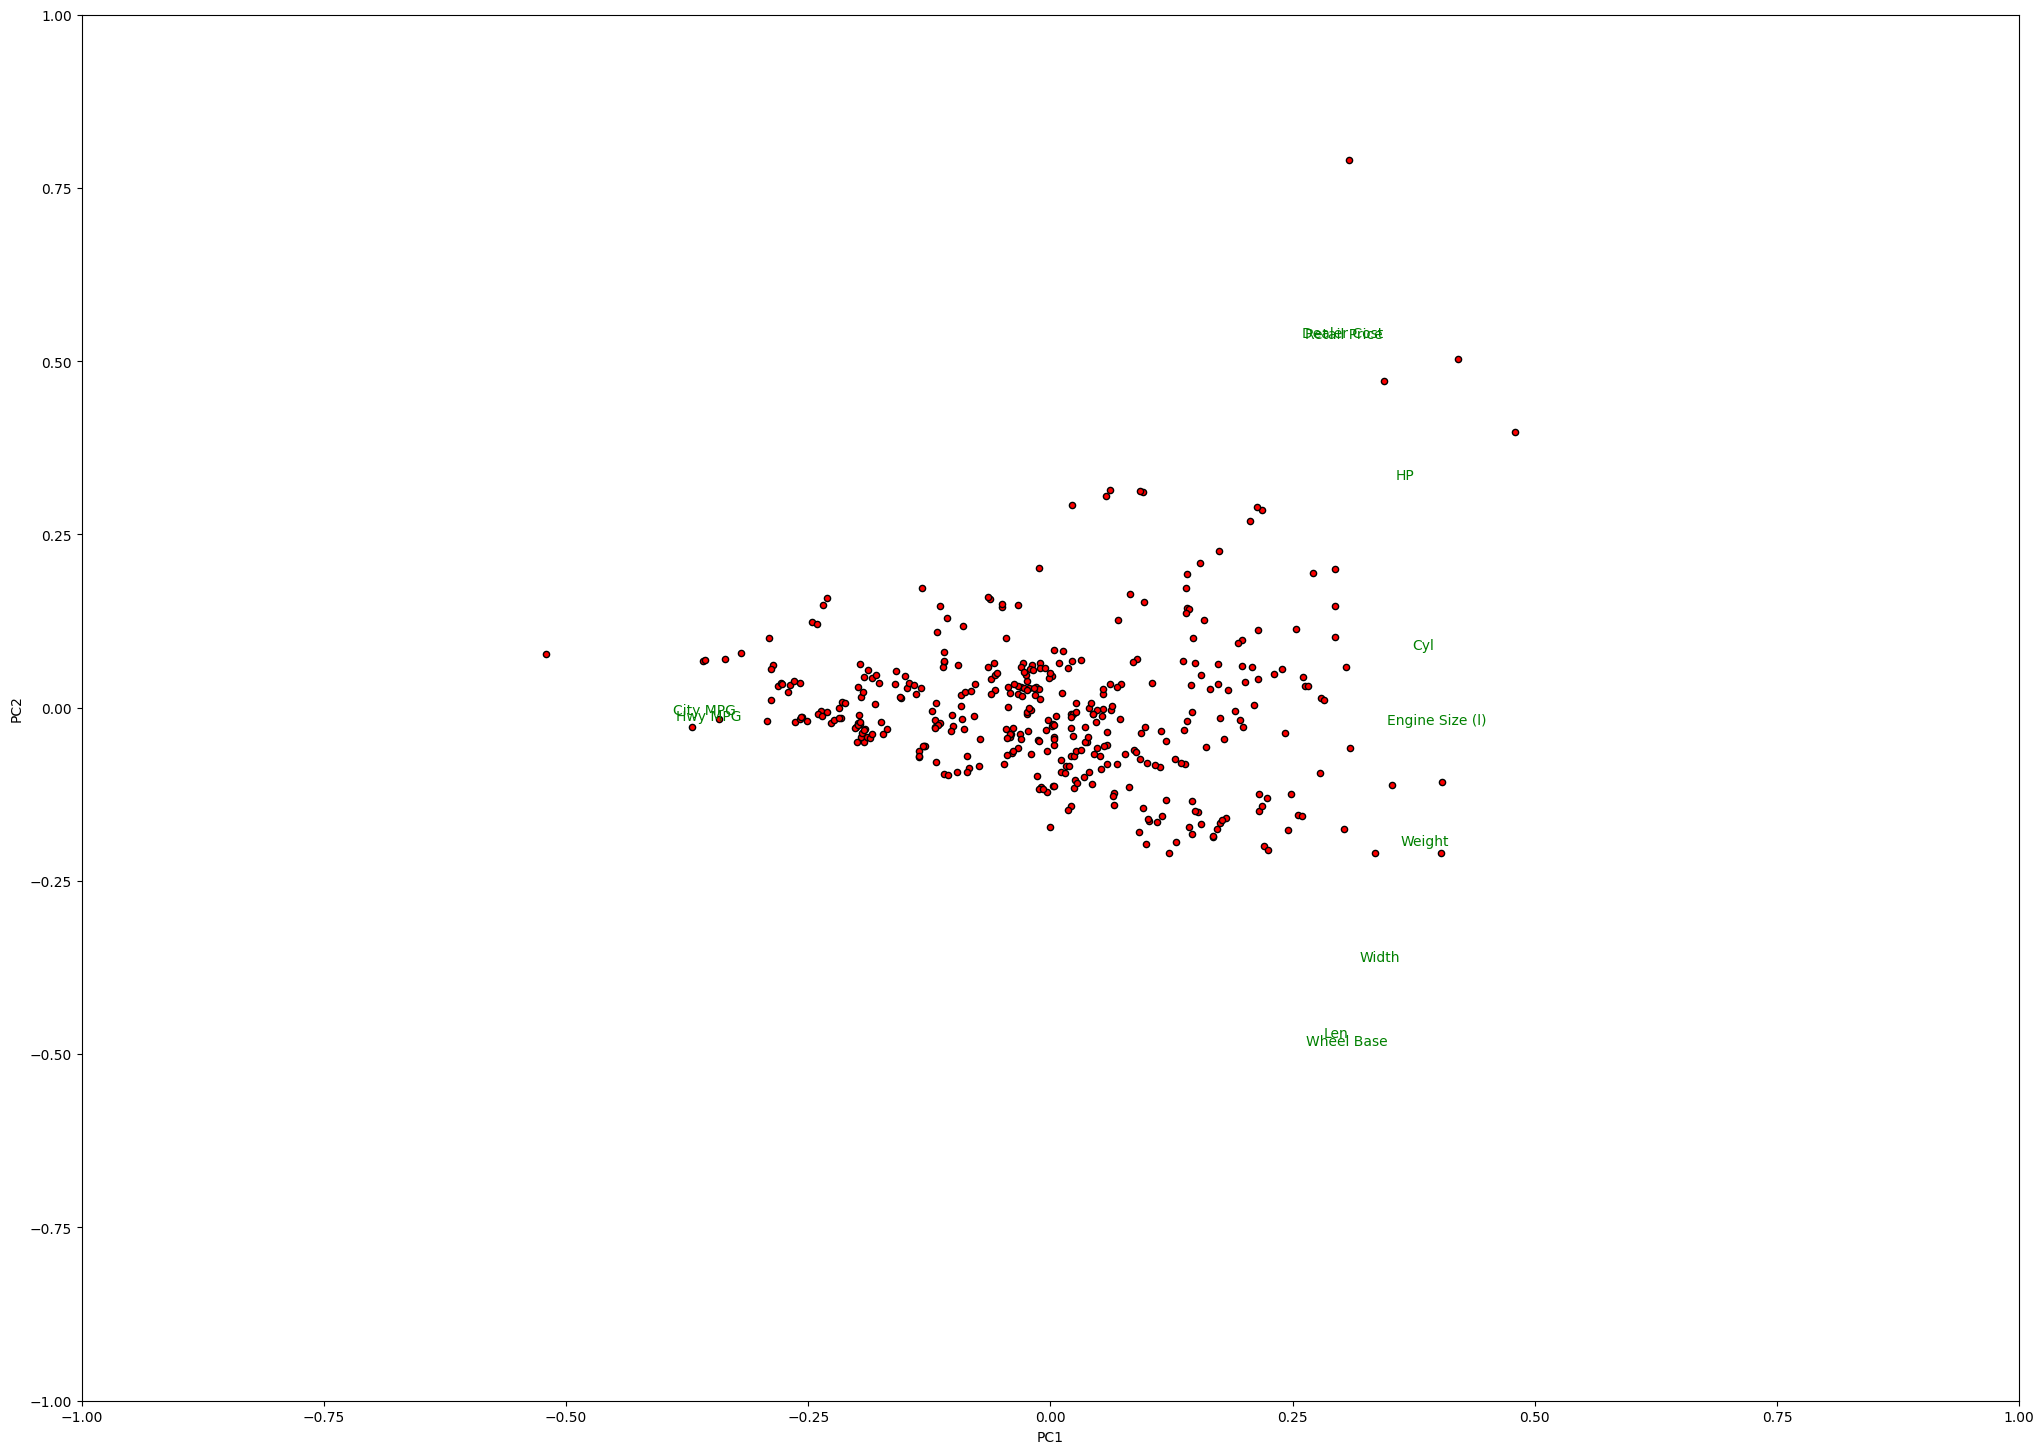

In [20]:
biplot(X_pca, np.transpose(pca.components_[0:2, :]), labels=attributes)

- **Arrow direction** shows the attribute's orientation in PC1–PC2 space.
- **Arrow length** indicates how much that attribute contributes to variance.
- **Arrows pointing in the same direction** → strongly positively correlated (Retail Price & Dealer Cost).
- **Opposite-pointing arrows** → negatively correlated (MPG arrows point opposite to Engine Size / Weight).
- **Perpendicular arrows** → near-zero correlation (e.g. Wheel Base vs. Retail Price).
- **Cars near an arrow tip** score high on that attribute; cars near the origin are average across all features.


## LFW data analysis


In [21]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.4)
X_lfw = lfw.data
y_lfw = lfw.target
target_names_lfw = lfw.target_names
h, w = lfw.images.shape[1], lfw.images.shape[2]

print(f"Dataset: {X_lfw.shape[0]} samples, {X_lfw.shape[1]} features ({h}x{w} pixels)")
print(
    f"Classes ({len(target_names_lfw)}): {list(str(name) for name in target_names_lfw)}"
)

X_train_lfw, X_test_lfw, y_train_lfw, y_test_lfw = train_test_split(
    X_lfw, y_lfw, test_size=0.3, random_state=42, stratify=y_lfw
)

print(f"Train: {X_train_lfw.shape[0]} samples")
print(f"Test: {X_test_lfw.shape[0]} samples")

Dataset: 1560 samples, 1850 features (50x37 pixels)
Classes (12): ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder', 'Hugo Chavez', 'Jacques Chirac', 'Jean Chretien', 'John Ashcroft', 'Junichiro Koizumi', 'Serena Williams', 'Tony Blair']
Train: 1092 samples
Test: 468 samples


In [22]:
n_components_lfw = 100
pca_lfw = PCA(
    n_components=n_components_lfw, whiten=True, svd_solver="randomized", random_state=42
)
X_train_pca = pca_lfw.fit_transform(X_train_lfw)
X_test_pca = pca_lfw.transform(X_test_lfw)

In [23]:
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1000, gamma=0.005, class_weight="balanced", random_state=42)
svm.fit(X_train_pca, y_train_lfw)

print(
    classification_report(
        y_test_lfw, svm.predict(X_test_pca), target_names=target_names_lfw
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       0.79      0.65      0.71        23
     Colin Powell       0.74      0.90      0.82        71
  Donald Rumsfeld       0.76      0.69      0.72        36
    George W Bush       0.84      0.93      0.88       159
Gerhard Schroeder       0.77      0.82      0.79        33
      Hugo Chavez       0.92      0.52      0.67        21
   Jacques Chirac       0.73      0.50      0.59        16
    Jean Chretien       0.92      0.69      0.79        16
    John Ashcroft       0.79      0.69      0.73        16
Junichiro Koizumi       1.00      0.67      0.80        18
  Serena Williams       1.00      0.62      0.77        16
       Tony Blair       0.72      0.79      0.76        43

         accuracy                           0.80       468
        macro avg       0.83      0.71      0.75       468
     weighted avg       0.81      0.80      0.80       468



In [24]:
mlp = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=500, random_state=42)
mlp.fit(X_train_pca, y_train_lfw)

print(
    classification_report(
        y_test_lfw, mlp.predict(X_test_pca), target_names=target_names_lfw
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       0.68      0.65      0.67        23
     Colin Powell       0.80      0.79      0.79        71
  Donald Rumsfeld       0.79      0.61      0.69        36
    George W Bush       0.85      0.94      0.89       159
Gerhard Schroeder       0.62      0.76      0.68        33
      Hugo Chavez       0.92      0.57      0.71        21
   Jacques Chirac       0.57      0.50      0.53        16
    Jean Chretien       0.80      0.75      0.77        16
    John Ashcroft       0.77      0.62      0.69        16
Junichiro Koizumi       1.00      0.61      0.76        18
  Serena Williams       0.92      0.69      0.79        16
       Tony Blair       0.62      0.77      0.69        43

         accuracy                           0.78       468
        macro avg       0.78      0.69      0.72       468
     weighted avg       0.79      0.78      0.78       468



In [29]:
pca_lfw_50 = PCA(n_components=50, whiten=True, svd_solver="randomized", random_state=42)
X_train_50 = pca_lfw_50.fit_transform(X_train_lfw)
X_test_50 = pca_lfw_50.transform(X_test_lfw)

In [30]:
svm_50 = SVC(
    kernel="rbf", C=1000, gamma=0.005, class_weight="balanced", random_state=42
)
svm_50.fit(X_train_50, y_train_lfw)


print(
    classification_report(
        y_test_lfw, svm_50.predict(X_test_50), target_names=target_names_lfw
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       0.57      0.70      0.63        23
     Colin Powell       0.86      0.83      0.84        71
  Donald Rumsfeld       0.76      0.69      0.72        36
    George W Bush       0.86      0.91      0.88       159
Gerhard Schroeder       0.63      0.73      0.68        33
      Hugo Chavez       1.00      0.86      0.92        21
   Jacques Chirac       0.62      0.62      0.62        16
    Jean Chretien       0.75      0.75      0.75        16
    John Ashcroft       0.67      0.75      0.71        16
Junichiro Koizumi       0.93      0.72      0.81        18
  Serena Williams       0.93      0.81      0.87        16
       Tony Blair       0.80      0.65      0.72        43

         accuracy                           0.80       468
        macro avg       0.78      0.75      0.76       468
     weighted avg       0.81      0.80      0.80       468



In [31]:
mlp_50 = MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=500, random_state=42)
mlp_50.fit(X_train_50, y_train_lfw)

print(
    classification_report(
        y_test_lfw, mlp_50.predict(X_test_50), target_names=target_names_lfw
    )
)

                   precision    recall  f1-score   support

     Ariel Sharon       0.70      0.70      0.70        23
     Colin Powell       0.86      0.85      0.85        71
  Donald Rumsfeld       0.74      0.72      0.73        36
    George W Bush       0.88      0.92      0.90       159
Gerhard Schroeder       0.68      0.70      0.69        33
      Hugo Chavez       0.89      0.76      0.82        21
   Jacques Chirac       0.75      0.56      0.64        16
    Jean Chretien       0.68      0.81      0.74        16
    John Ashcroft       0.58      0.69      0.63        16
Junichiro Koizumi       1.00      0.72      0.84        18
  Serena Williams       1.00      0.81      0.90        16
       Tony Blair       0.73      0.77      0.75        43

         accuracy                           0.81       468
        macro avg       0.79      0.75      0.77       468
     weighted avg       0.82      0.81      0.81       468



> f1-score is mostly the same for 100 and 50 components
>
> precision is slighly lower for 50 components, recall is slighly higher for 50 components


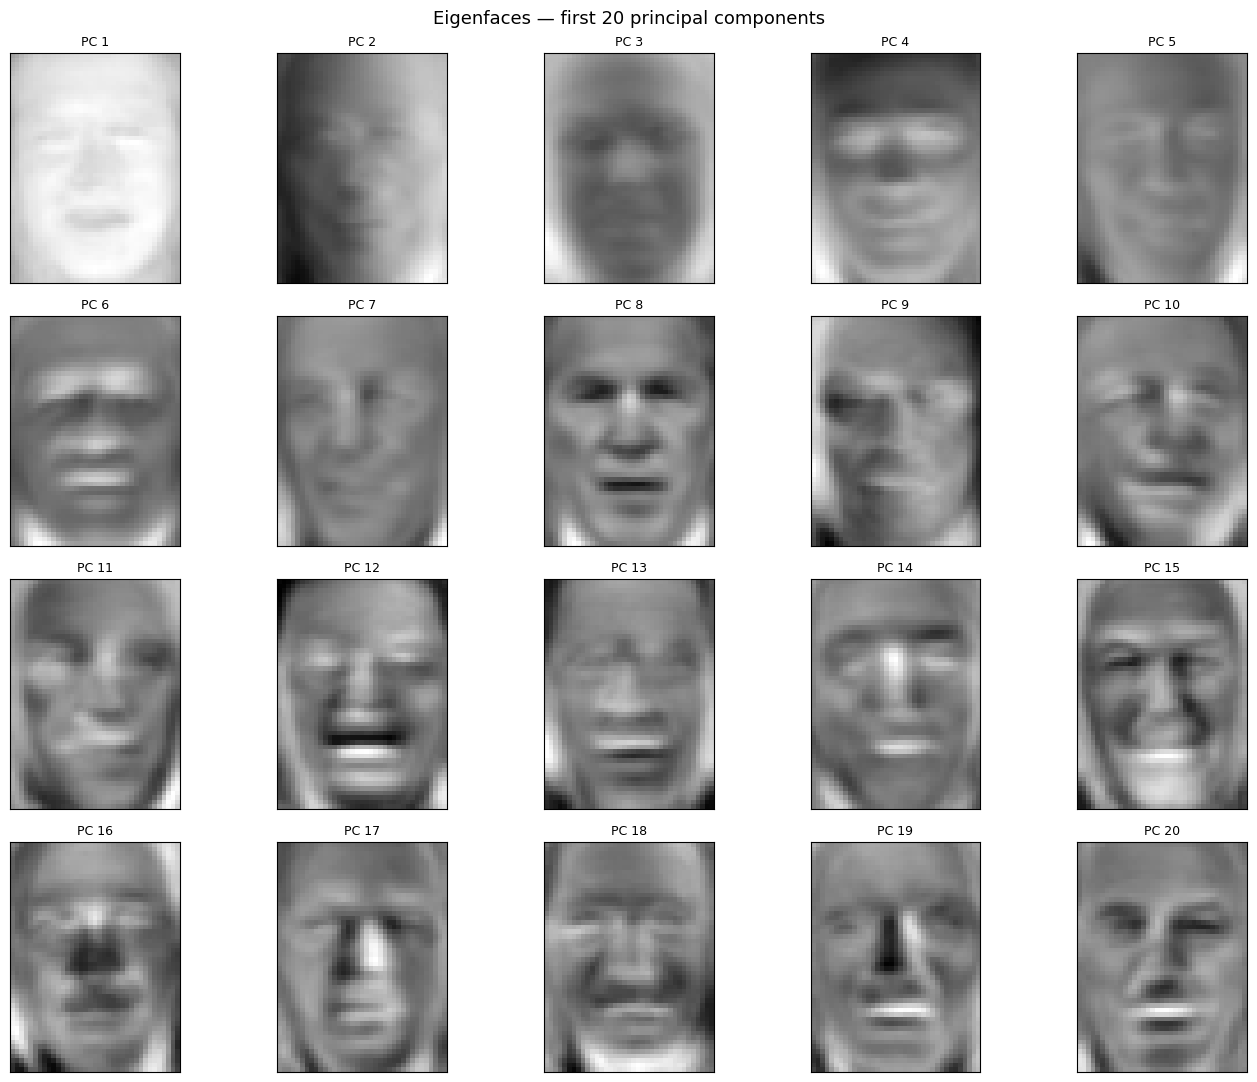

In [28]:
n_eigenfaces = 20
eigenfaces = pca_lfw.components_[:n_eigenfaces].reshape((n_eigenfaces, h, w))

fig, axes = plt.subplots(
    4, 5, figsize=(14, 11), subplot_kw={"xticks": [], "yticks": []}
)
for i, ax in enumerate(axes.flat):
    vmax = np.abs(eigenfaces[i]).max()
    ax.imshow(
        eigenfaces[i], cmap="gray", vmin=-vmax, vmax=vmax, interpolation="nearest"
    )
    ax.set_title(f"PC {i + 1}", fontsize=9)
plt.suptitle("Eigenfaces — first 20 principal components", fontsize=13)
plt.tight_layout()
plt.show()

> Eigenfaces can be interpreted in terms of amount of information they capture about the dataset.
>
> The first focus on general features like shape of the face, the later ones capture eyesockets, nose, mouth, etc.


## IPCA on synthetic blobs


In [41]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X_blob, y_blob = make_blobs(
    n_samples=100_000, n_features=100, centers=5, random_state=42
)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_blob_train_s = scaler.fit_transform(X_blob_train)
X_blob_test_s = scaler.transform(X_blob_test)

print(f"Train: {X_blob_train_s.shape}")
print(f"Test: {X_blob_test_s.shape}")

Train: (80000, 100)
Test: (20000, 100)


In [42]:
import time
import tracemalloc

n_pcs = 10

tracemalloc.start()
t0 = time.perf_counter()

pca_full = PCA(n_components=n_pcs, random_state=42)
X_train_pca_full = pca_full.fit_transform(X_blob_train_s)
X_test_pca_full = pca_full.transform(X_blob_test_s)

t_pca = time.perf_counter() - t0
_, mem_pca = tracemalloc.get_traced_memory()
tracemalloc.stop()

var_pca = pca_full.explained_variance_ratio_
mse_pca = np.mean((X_blob_test_s - pca_full.inverse_transform(X_test_pca_full)) ** 2)

print(f"PCA  — time: {t_pca:.3f}s | peak memory: {mem_pca / 1e6:.1f} MB")
print(f"PCA  — explained variance (10 PCs): {var_pca.sum():.4f}")
print(f"PCA  — reconstruction MSE (test):   {mse_pca:.6f}")

PCA  — time: 0.043s | peak memory: 8.1 MB
PCA  — explained variance (10 PCs): 0.9662
PCA  — reconstruction MSE (test):   0.033796


In [43]:
import time
import tracemalloc

from sklearn.decomposition import IncrementalPCA

batch_size = 1000

tracemalloc.start()
t0 = time.perf_counter()

ipca = IncrementalPCA(n_components=n_pcs, batch_size=batch_size)
for i in range(0, X_blob_train_s.shape[0], batch_size):
    ipca.partial_fit(X_blob_train_s[i : i + batch_size])

X_train_ipca = ipca.transform(X_blob_train_s)
X_test_ipca = ipca.transform(X_blob_test_s)

t_ipca = time.perf_counter() - t0
_, mem_ipca = tracemalloc.get_traced_memory()
tracemalloc.stop()

var_ipca = ipca.explained_variance_ratio_
assert var_ipca is not None
mse_ipca = np.mean((X_blob_test_s - ipca.inverse_transform(X_test_ipca)) ** 2)

print(f"IPCA — time: {t_ipca:.3f}s | peak memory: {mem_ipca / 1e6:.1f} MB")
print(f"IPCA — explained variance (10 PCs): {var_ipca.sum():.4f}")
print(f"IPCA — reconstruction MSE (test):   {mse_ipca:.6f}")

IPCA — time: 0.950s | peak memory: 8.2 MB
IPCA — explained variance (10 PCs): 0.9662
IPCA — reconstruction MSE (test):   0.033800


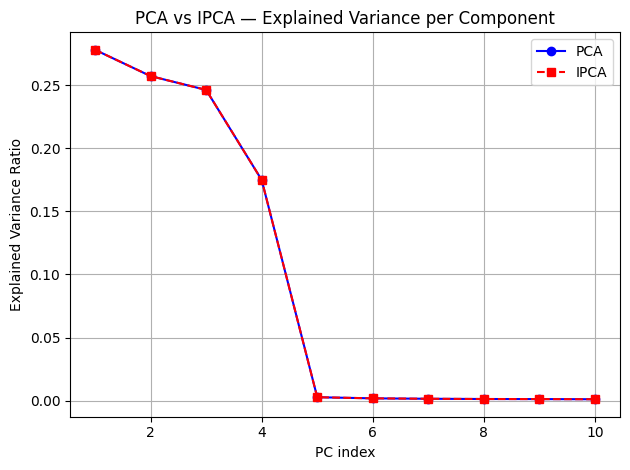

                              PCA         IPCA
Explained var (10 PCs)       0.9662       0.9662
Recon. MSE (test)        0.033796     0.033800
Fit time (s)                0.043        0.950
Peak memory (MB)              8.1          8.2


In [47]:
x_ticks = np.arange(1, n_pcs + 1)
plt.plot(x_ticks, var_pca, "bo-", label="PCA")
plt.plot(x_ticks, var_ipca, "rs--", label="IPCA")
plt.xlabel("PC index")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA vs IPCA — Explained Variance per Component")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print(f"{'':20s} {'PCA':>12} {'IPCA':>12}")
print(f"{'Explained var (10 PCs)':<20} {var_pca.sum():>12.4f} {var_ipca.sum():>12.4f}")
print(f"{'Recon. MSE (test)':<20} {mse_pca:>12.6f} {mse_ipca:>12.6f}")
print(f"{'Fit time (s)':<20} {t_pca:>12.3f} {t_ipca:>12.3f}")
print(f"{'Peak memory (MB)':<20} {mem_pca / 1e6:>12.1f} {mem_ipca / 1e6:>12.1f}")

> The results for IPCA and PCA are very similar. IPCA took more time to fit.


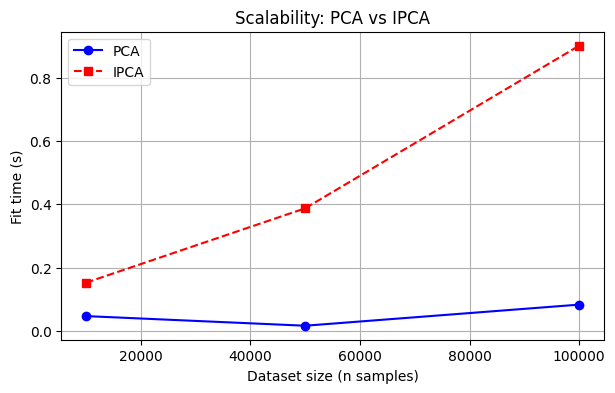

In [48]:
from sklearn.decomposition import IncrementalPCA as IPCA_tmp

sizes = [10_000, 50_000, 100_000]
times_pca_scale = []
times_ipca_scale = []

for n in sizes:
    X_s, _ = make_blobs(n_samples=n, n_features=100, centers=5, random_state=42)
    X_s = StandardScaler().fit_transform(X_s)

    t0 = time.perf_counter()
    PCA(n_components=10, random_state=42).fit(X_s)
    times_pca_scale.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    ipca_s = IPCA_tmp(n_components=10, batch_size=1000)
    for i in range(0, n, 1000):
        ipca_s.partial_fit(X_s[i : i + 1000])
    times_ipca_scale.append(time.perf_counter() - t0)

plt.figure(figsize=(7, 4))
plt.plot(sizes, times_pca_scale, "bo-", label="PCA")
plt.plot(sizes, times_ipca_scale, "rs--", label="IPCA")
plt.xlabel("Dataset size (n samples)")
plt.ylabel("Fit time (s)")
plt.title("Scalability: PCA vs IPCA")
plt.legend()
plt.grid()
plt.show()

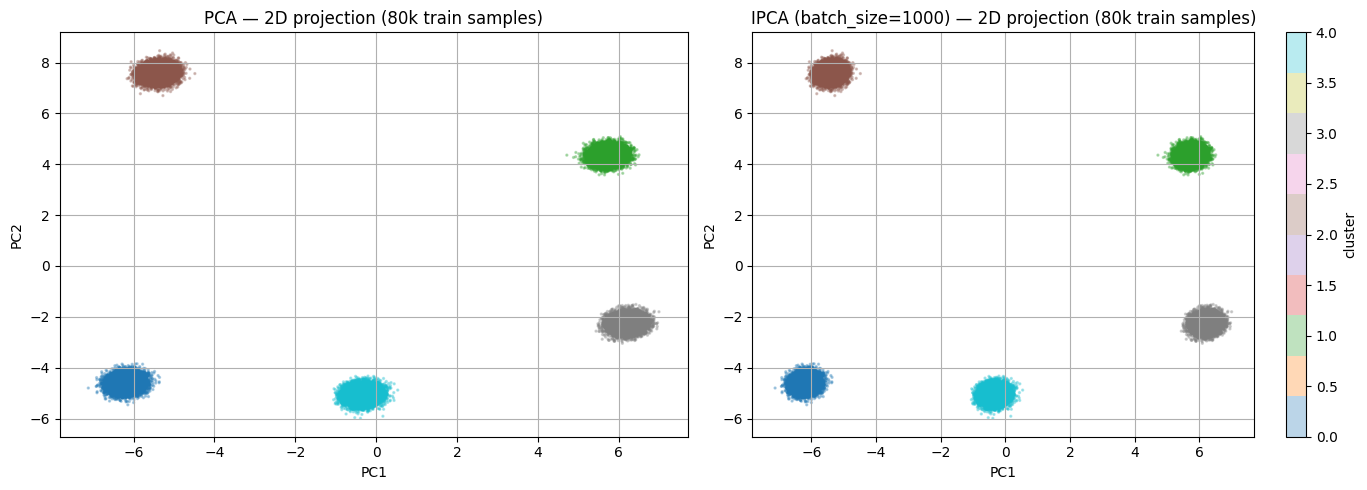

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_2d, title in zip(
    axes,
    [X_train_pca_full[:, :2], X_train_ipca[:, :2]],
    ["PCA", "IPCA (batch_size=1000)"],
):
    sc = ax.scatter(
        X_2d[:, 0], X_2d[:, 1], c=y_blob_train, cmap="tab10", s=2, alpha=0.3
    )
    ax.set_title(f"{title} — 2D projection (80k train samples)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid()

plt.colorbar(sc, ax=axes[1], label="cluster")
plt.tight_layout()
plt.show()

**1. Does IPCA produce similar results to PCA? in regards to explained variance?**

> Yes — IPCA converges to basically the same results as full PCA after processing sufficient amounts of data through `partial_fit()`.

**2. How does the execution time of IPCA change with respect to `batch_size` (e.g., 100 vs 5000)?**

> _Small `batch_size` (e.g., 100):_ many calls to `partial_fit()` -> higher overhead per call, slower execution, but minimal memory usage.
> _Large `batch_size` (e.g., 5000):_ fewer calls, each processing more data -> faster, but memory usage approaches that of full PCA.

**3. In which practical scenarios is IPCA preferred over PCA?**

> Dataset is too large to fit in memory (e.g. large image collections)
> Data arrives in a stream or batches (e.g. real-time iot sensor data)

**4. Why might the reconstruction error be higher for IPCA than for PCA?**

> IPCA calculates incremental SVD. With a small `batch_size`, each batch provides only a partial view of the global covariance structure, causing components to be slightly rotated or compressed relative to the global PCA solution.
